# Step 01 — Pre-Training Dataset Characterization

## tl;dr

This is a train/validation-only diagnostic data audit. It verifies the corrected LiTS manifest, profiles source-NIfTI acquisition geometry, 3D tumour morphology, HU contrast, train-to-validation shift, leakage risk, label quality, frozen predicted-liver ROI coverage, and associations with the existing Mark 4E validation diagnostics. It then writes a dataset data card, a train-derived sampling policy, and a machine-readable gate.

**Execution status on delivery:** structurally validated and safely preflighted, but intentionally not fully executed. Use **Restart Kernel and Run All** to create the complete output set. Full execution reads every train/validation source volume and may take substantial CPU time and memory.

**Non-negotiable test lock:** the manifest may be counted to prove the frozen split, but test paths are never dereferenced, hashed, loaded, sampled, summarized, or used in any policy.

## Context & Methods

The authoritative dataset is `build_corrected_20260713_214847_v2`, with expected manifest SHA-256 `575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63c1bfc6c2c615861889`. Source NIfTI is used for geometry, labels, lesions, and HU. Derived 256×256 masks are loaded only for manifest-count reconciliation and frozen ROI comparisons.

### Key Assumptions

- LiTS source labels are 0 background, 1 liver, and 2 tumour; liver support is `segmentation > 0`, tumour is `segmentation == 2`.
- The approved in-plane `rot180` transform is applied when comparing source arrays with derived artifacts. Rotation does not alter physical volumes or 3D component sizes.
- Train-derived robust bounds, bin edges, scaling, analog distances, and sampling rules are frozen before validation is mapped into them.
- Validation is descriptive only. No validation-specific weighting, transform, threshold, or per-patient rule is created.
- Existing Mark 4E diagnostic tables are joined only after dataset feature computation.
- Correlation is reported as association, never causation.

## Data

### 1. Imports, paths, parameters, and output contract

In [1]:
from __future__ import annotations

import hashlib, json, math, os, platform, sys, warnings
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
from PIL import Image
from scipy import ndimage, stats
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

PROJECT_ROOT = Path(r"D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver")
PART2_ROOT = PROJECT_ROOT / "mark 1 (part 2)"
PHASE_DIR = PART2_ROOT / "step_01_pretraining_dataset_characterization"
OUTPUT_DIR = PHASE_DIR / "outputs"
DATASET_ROOT = Path(r"D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver\02_staging\build_corrected_20260713_214847_v2")
MANIFEST_PATH = DATASET_ROOT / "manifests" / "slice_manifest.csv"
EXPECTED_MANIFEST_SHA256 = "575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63c1bfc6c2c615861889"
MARK4D_DIR = PROJECT_ROOT / "mark 1" / "mark_4d_outputs"
MARK4E_DIR = PROJECT_ROOT / "mark 1" / "mark_4e_outputs"
TRAIN_ROI_PATH = PROJECT_ROOT / "mark 1" / "mark_3_outputs" / "training_roi_manifest.csv"
VAL_ROI_PATH = PROJECT_ROOT / "mark 1" / "mark_4_outputs" / "validation_roi_manifest.csv"

ALLOWED_SPLITS = ("train", "val")
TEST_SPLIT_NAME = "test"
TEST_IMAGES_ACCESSED = False
RANDOM_SEED = 42
CONNECTIVITY_DEFAULT = 6
CONNECTIVITY_SENSITIVITY = 26
OUTLIER_IQR_MULTIPLIER = 1.5
BROAD_WINDOW = (-160.0, 240.0)
LIVER_WINDOW = (0.0, 200.0)
HU_HISTOGRAM_BINS = np.arange(-300, 401, 10, dtype=float)
ROI_LIVER_THRESHOLD = 0.50
ROI_COMPONENT_RULE = "largest_3d"
ROI_PADDING_PIXELS = 16
ANALOG_TOP_K = 5
MIN_COMPONENT_ML_FOR_PRIMARY_BINS = 0.001
MANIFEST_MASK_SAMPLE_PER_SPLIT = 64
EDGE_ALIGNMENT_CASES = 12
FLOAT_PRECISION = "%.6f"

EXPECTED_OUTPUTS = [
    "configuration.json", "provenance.json", "manifest_quality_summary.csv", "integrity_failures.csv",
    "split_summary.csv", "data_quality_gate.json", "volume_geometry_profile.csv", "geometry_split_comparison.csv",
    "geometry_outliers.csv", "geometry_dashboard.png", "patient_burden_profile.csv", "lesion_component_profile.csv",
    "train_derived_lesion_bins.json", "lesion_distribution_dashboard.png", "validation_stratum_coverage.csv",
    "hu_contrast_per_slice.csv", "hu_contrast_per_volume.csv", "appearance_feature_profile.csv",
    "validation_training_analogs.csv", "v104_v116_domain_dashboard.png", "intensity_distribution_dashboard.png",
    "label_qc_per_volume.csv", "label_qc_review_cases.csv", "label_alignment_review.png", "roi_coverage_review.csv",
    "difficulty_feature_associations.csv", "patient_difficulty_profile.csv", "difficulty_dashboard.png",
    "patient_metrics.csv", "slice_metrics.csv", "lesion_or_size_metrics.csv", "DATASET_DATA_CARD.md",
    "sampling_policy.json", "pretraining_dataset_gate.json", "expected_vs_actual.csv", "gate_result.json"
]

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
np.random.seed(RANDOM_SEED)
assert OUTPUT_DIR.resolve().parent == PHASE_DIR.resolve()
assert TEST_IMAGES_ACCESSED is False
print(f"Output directory: {OUTPUT_DIR}")
print("Mode: DIAGNOSTIC; allowed splits only:", ALLOWED_SPLITS)

Output directory: D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver\mark 1 (part 2)\step_01_pretraining_dataset_characterization\outputs
Mode: DIAGNOSTIC; allowed splits only: ('train', 'val')


### 2. Reusable deterministic helpers

In [2]:
def sha256_file(path: Path, chunk_size: int = 1 << 20) -> str:
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()

def write_json(path: Path, payload: dict) -> None:
    path.write_text(json.dumps(payload, indent=2, sort_keys=True, default=str), encoding="utf-8")

def save_csv(frame: pd.DataFrame, name: str) -> None:
    frame.to_csv(OUTPUT_DIR / name, index=False, float_format=FLOAT_PRECISION)

def resolved_derived_path(value: str) -> Path:
    candidate = Path(str(value))
    return candidate if candidate.is_absolute() else DATASET_ROOT / candidate

def approved_transform(array: np.ndarray, transform: str) -> np.ndarray:
    if transform == "identity": return array
    if transform == "rot180": return np.rot90(array, 2, axes=(0, 1))
    raise ValueError(f"Unexpected transform: {transform}")

def connectivity_structure(connectivity: int) -> np.ndarray:
    if connectivity == 6: return ndimage.generate_binary_structure(3, 1)
    if connectivity == 26: return ndimage.generate_binary_structure(3, 3)
    raise ValueError(connectivity)

def robust_bounds(series: pd.Series, multiplier: float = OUTLIER_IQR_MULTIPLIER):
    clean = pd.to_numeric(series, errors="coerce").dropna()
    if clean.empty: return np.nan, np.nan, np.nan, np.nan
    q1, q3 = clean.quantile([0.25, 0.75])
    iqr = q3 - q1
    return float(q1), float(q3), float(q1 - multiplier * iqr), float(q3 + multiplier * iqr)

def standardized_difference(train: pd.Series, val: pd.Series) -> float:
    a = pd.to_numeric(train, errors="coerce").dropna().to_numpy(float)
    b = pd.to_numeric(val, errors="coerce").dropna().to_numpy(float)
    if len(a) < 2 or len(b) < 2: return np.nan
    pooled = math.sqrt((np.var(a, ddof=1) + np.var(b, ddof=1)) / 2)
    return float((np.mean(b) - np.mean(a)) / pooled) if pooled > 0 else 0.0

def quantile_summary(frame: pd.DataFrame, features: list[str]) -> pd.DataFrame:
    rows = []
    for feature in features:
        for split, group in frame.groupby("split"):
            values = pd.to_numeric(group[feature], errors="coerce").dropna()
            row = {"feature": feature, "split": split, "count": len(values)}
            for q in [0, .05, .25, .5, .75, .95, 1]: row[f"q{int(q*100):02d}"] = values.quantile(q) if len(values) else np.nan
            row["mean"] = values.mean() if len(values) else np.nan
            row["std"] = values.std() if len(values) else np.nan
            rows.append(row)
    out = pd.DataFrame(rows)
    for feature in features:
        mask = out.feature.eq(feature)
        smd = standardized_difference(frame.loc[frame.split.eq("train"), feature], frame.loc[frame.split.eq("val"), feature])
        out.loc[mask, "validation_minus_train_standardized_difference"] = smd
    return out

def dice_from_counts(intersection, truth_pixels, predicted_pixels, eps=1e-7):
    return (2 * intersection + eps) / (truth_pixels + predicted_pixels + eps)

def window_visibility(values: np.ndarray, low: float, high: float) -> float:
    values = np.asarray(values, dtype=float)
    if values.size == 0: return np.nan
    return float(np.mean((values >= low) & (values <= high)))

def compactness_proxy(mask: np.ndarray, voxel_volume_mm3: float) -> float:
    if not mask.any(): return np.nan
    eroded = ndimage.binary_erosion(mask, structure=connectivity_structure(6), border_value=0)
    surface_voxels = int(np.count_nonzero(mask & ~eroded))
    volume_mm3 = int(mask.sum()) * voxel_volume_mm3
    return float(surface_voxels / max(volume_mm3, 1e-12))

def edge_dice(image2d: np.ndarray, mask2d: np.ndarray) -> float:
    grad = ndimage.gaussian_gradient_magnitude(image2d.astype(float), sigma=1.0)
    boundary = mask2d ^ ndimage.binary_erosion(mask2d)
    if not boundary.any(): return np.nan
    high_grad = grad >= np.quantile(grad, 0.90)
    proximity = ndimage.binary_dilation(high_grad, iterations=2)
    return float(np.mean(proximity[boundary]))

def derive_train_edges(values: pd.Series, quantiles=(0, .25, .5, .75, 1)) -> list[float]:
    clean = pd.to_numeric(values, errors="coerce").dropna().to_numpy(float)
    if not len(clean): return []
    edges = np.unique(np.quantile(clean, quantiles)).astype(float)
    if len(edges) == 1: edges = np.array([edges[0], np.nextafter(edges[0], np.inf)])
    edges[0], edges[-1] = -np.inf, np.inf
    return edges.tolist()

def assign_bin(values: pd.Series, edges: list[float], prefix: str) -> pd.Series:
    labels = [f"{prefix}_q{i+1}" for i in range(len(edges)-1)]
    return pd.cut(values, bins=edges, labels=labels, include_lowest=True, duplicates="drop").astype("string")

### 3. Load manifest metadata, enforce the test lock, and write configuration

In [3]:
manifest_hash = sha256_file(MANIFEST_PATH)
if manifest_hash != EXPECTED_MANIFEST_SHA256:
    raise RuntimeError(f"CRITICAL STOP: manifest hash mismatch: {manifest_hash}")

manifest_all = pd.read_csv(MANIFEST_PATH)
test_rows = manifest_all.loc[manifest_all["split"].eq(TEST_SPLIT_NAME), ["sample_id", "volume_id", "split"]].copy()
manifest = manifest_all.loc[manifest_all["split"].isin(ALLOWED_SPLITS)].copy()
del manifest_all
assert set(manifest["split"].unique()) <= set(ALLOWED_SPLITS)
assert not manifest["split"].eq(TEST_SPLIT_NAME).any()
assert TEST_IMAGES_ACCESSED is False

configuration = {
    "phase": "step_01_pretraining_dataset_characterization", "mode": "DIAGNOSTIC",
    "project_root": str(PROJECT_ROOT), "phase_dir": str(PHASE_DIR), "output_dir": str(OUTPUT_DIR),
    "dataset_build_id": "build_corrected_20260713_214847_v2", "dataset_root": str(DATASET_ROOT),
    "manifest_path": str(MANIFEST_PATH), "manifest_sha256": manifest_hash,
    "allowed_splits": list(ALLOWED_SPLITS), "test_split_locked": True, "test_images_accessed": False,
    "random_seed": RANDOM_SEED, "source_type": "source NIfTI; derived PNG only for reconciliation",
    "label_semantics": {"background": 0, "liver_including_tumour": "segmentation > 0", "tumour": 2},
    "orientation_handling": {"identity": "unchanged", "rot180": "rotate both image and segmentation 180 degrees in-plane for derived alignment"},
    "hu_windows": {"broad": BROAD_WINDOW, "liver": LIVER_WINDOW}, "hu_histogram_bins": HU_HISTOGRAM_BINS.tolist(),
    "connectivity": {"default": CONNECTIVITY_DEFAULT, "tiny_component_sensitivity": CONNECTIVITY_SENSITIVITY},
    "outlier_rule": f"train Q1/Q3 plus or minus {OUTLIER_IQR_MULTIPLIER} x IQR; label only",
    "roi": {"source": "frozen predicted-liver Mark 3/4 manifests", "liver_threshold": ROI_LIVER_THRESHOLD,
            "component_rule": ROI_COMPONENT_RULE, "padding_pixels": ROI_PADDING_PIXELS, "resize": [256, 256],
            "mask_interpolation": "nearest", "image_interpolation": "bilinear"},
    "analog_search": {"scaler": "RobustScaler fit on train only", "distance": "Euclidean in train-scaled feature space", "top_k": ANALOG_TOP_K},
    "sampling_policy": {"definitions": "train only", "validation_role": "coverage mapping only", "seed": RANDOM_SEED},
    "full_analysis_executed": False, "expected_outputs": EXPECTED_OUTPUTS,
}
write_json(OUTPUT_DIR / "configuration.json", configuration)
print(f"Manifest verified: {manifest_hash}; train/val rows={len(manifest):,}; locked test rows counted={len(test_rows):,}")

Manifest verified: 575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63c1bfc6c2c615861889; train/val rows=51,352; locked test rows counted=7,286


## Results

### 4. Section A — manifest, integrity, leakage, and sampled mask reconciliation

In [4]:
REQUIRED_COLUMNS = [
    "sample_id", "volume_id", "slice_index", "image_path", "organ_mask_path", "tumor_mask_path",
    "source_volume_path", "source_segmentation_path", "source_volume_sha256", "source_segmentation_sha256",
    "transform_applied", "organ_pixels", "tumor_pixels", "organ_present", "tumor_present", "split",
    "verification_status", "manual_spatial_status", "automatic_integrity_pass", "exclusion_reason", "build_id"
]
failures = []
def fail(check, severity, detail, sample_id=None, volume_id=None):
    failures.append({"check": check, "severity": severity, "detail": detail, "sample_id": sample_id, "volume_id": volume_id})

missing_columns = sorted(set(REQUIRED_COLUMNS) - set(manifest.columns))
if missing_columns: fail("required_columns", "critical", repr(missing_columns))
for col in sorted(set(REQUIRED_COLUMNS) & set(manifest.columns)):
    count = int(manifest[col].isna().sum())
    if count and col != "exclusion_reason": fail("required_column_missingness", "critical", f"{col}: {count}")
if not manifest.sample_id.is_unique: fail("sample_id_unique", "critical", "duplicate sample_id")
if manifest.duplicated(["volume_id", "slice_index"]).any(): fail("volume_slice_unique", "critical", "duplicate volume_id/slice_index")

split_volume_sets = {s: set(g.volume_id.unique()) for s, g in manifest.groupby("split")}
overlap = split_volume_sets.get("train", set()) & split_volume_sets.get("val", set())
if overlap: fail("patient_split_disjoint", "critical", repr(sorted(overlap)))
source_overlap = set(manifest.loc[manifest.split.eq("train"), "source_volume_sha256"]) & set(manifest.loc[manifest.split.eq("val"), "source_volume_sha256"])
if source_overlap: fail("source_hash_split_disjoint", "critical", repr(sorted(source_overlap)))

allowed_values = {"verification_status": {"verified"}, "manual_spatial_status": {"approved"},
                  "transform_applied": {"identity", "rot180"}, "build_id": {"build_corrected_20260713_214847_v2"}}
for col, allowed in allowed_values.items():
    unexpected = set(manifest[col].dropna().astype(str).unique()) - allowed
    if unexpected: fail(f"allowed_{col}", "critical", repr(sorted(unexpected)))
if not manifest.automatic_integrity_pass.fillna(False).all(): fail("automatic_integrity_pass", "critical", "false rows present")
exclusions = manifest.exclusion_reason.notna() & manifest.exclusion_reason.astype(str).str.strip().ne("")
if exclusions.any(): fail("unexpected_exclusions", "warning", f"{int(exclusions.sum())} rows")

unique_sources = manifest[["split", "volume_id", "source_volume_path", "source_segmentation_path", "source_volume_sha256", "source_segmentation_sha256"]].drop_duplicates("volume_id")
for row in unique_sources.itertuples(index=False):
    for kind in ("volume", "segmentation"):
        path = Path(getattr(row, f"source_{kind}_path"))
        if not path.is_file(): fail(f"source_{kind}_exists", "critical", str(path), volume_id=row.volume_id)
for col in ["image_path", "organ_mask_path", "tumor_mask_path"]:
    missing = manifest[col].map(lambda p: not resolved_derived_path(p).is_file())
    for row in manifest.loc[missing, ["sample_id", "volume_id", col]].head(100).itertuples(index=False):
        fail(f"{col}_exists", "critical", str(getattr(row, col)), row.sample_id, row.volume_id)

rng = np.random.default_rng(RANDOM_SEED)
sampled = []
for split, group in manifest.groupby("split"):
    indices = rng.choice(group.index.to_numpy(), size=min(MANIFEST_MASK_SAMPLE_PER_SPLIT, len(group)), replace=False)
    sampled.append(manifest.loc[indices])
sampled = pd.concat(sampled)
for row in sampled.itertuples(index=False):
    organ = np.asarray(Image.open(resolved_derived_path(row.organ_mask_path))) > 0
    tumour = np.asarray(Image.open(resolved_derived_path(row.tumor_mask_path))) > 0
    if organ.ndim == 3: organ = organ[..., 0]
    if tumour.ndim == 3: tumour = tumour[..., 0]
    if int(organ.sum()) != int(row.organ_pixels): fail("sampled_organ_pixels", "critical", f"loaded={organ.sum()}, manifest={row.organ_pixels}", row.sample_id, row.volume_id)
    if int(tumour.sum()) != int(row.tumor_pixels): fail("sampled_tumour_pixels", "critical", f"loaded={tumour.sum()}, manifest={row.tumor_pixels}", row.sample_id, row.volume_id)
    if np.any(tumour & ~organ): fail("sampled_tumour_containment", "critical", "tumour outside organ", row.sample_id, row.volume_id)

# Deterministic low-resolution derived-image signatures for near-duplicate review, train/val only.
def image_signature(path_value):
    arr = np.asarray(Image.open(resolved_derived_path(path_value)).convert("L").resize((16, 16), Image.Resampling.BILINEAR), dtype=np.uint8)
    return hashlib.sha256(arr.tobytes()).hexdigest()
signature_rows = manifest.groupby("volume_id", sort=True).nth([0, -1]).reset_index()
signature_rows["signature"] = signature_rows.image_path.map(image_signature)
sig_cross = signature_rows.groupby("signature").filter(lambda g: g.split.nunique() > 1)
if len(sig_cross): fail("near_duplicate_boundary_slice_signature", "warning", f"{len(sig_cross)} boundary slices share train/val signatures")

integrity_failures = pd.DataFrame(failures, columns=["check", "severity", "detail", "sample_id", "volume_id"])
split_summary = manifest.groupby("split").agg(slices=("sample_id", "size"), volumes=("volume_id", "nunique"), tumour_positive_slices=("tumor_present", "sum"), tumour_pixels=("tumor_pixels", "sum")).reset_index()
split_summary = pd.concat([split_summary, pd.DataFrame([{"split": "test_locked_metadata_only", "slices": len(test_rows), "volumes": test_rows.volume_id.nunique(), "tumour_positive_slices": np.nan, "tumour_pixels": np.nan}])], ignore_index=True)
quality_rows = [
    ("manifest_sha256_match", manifest_hash == EXPECTED_MANIFEST_SHA256, manifest_hash),
    ("row_count_train_val", len(manifest) == 51352, len(manifest)),
    ("column_count", len(manifest.columns) == 27, len(manifest.columns)),
    ("sample_id_unique", manifest.sample_id.is_unique, manifest.sample_id.nunique()),
    ("volume_slice_unique", not manifest.duplicated(["volume_id", "slice_index"]).any(), len(manifest)),
    ("train_val_volume_disjoint", not overlap, sorted(overlap)),
    ("train_val_source_hash_disjoint", not source_overlap, len(source_overlap)),
    ("required_source_files_exist", not (integrity_failures.check.str.contains("source_.*_exists", regex=True).any() if len(integrity_failures) else False), len(unique_sources)),
    ("sampled_mask_counts_match", not (integrity_failures.check.str.contains("sampled_.*pixels", regex=True).any() if len(integrity_failures) else False), len(sampled)),
    ("test_images_accessed_false", TEST_IMAGES_ACCESSED is False, False),
]
manifest_quality = pd.DataFrame(quality_rows, columns=["check", "passed", "observed"])
critical_count = int((integrity_failures.severity == "critical").sum()) if len(integrity_failures) else 0
data_quality_gate = {"status": "PASS" if critical_count == 0 else "FAIL", "critical_failure_count": critical_count,
                     "warning_count": int((integrity_failures.severity == "warning").sum()) if len(integrity_failures) else 0,
                     "manifest_sha256": manifest_hash, "test_images_accessed": False}
save_csv(manifest_quality, "manifest_quality_summary.csv"); save_csv(integrity_failures, "integrity_failures.csv"); save_csv(split_summary, "split_summary.csv")
write_json(OUTPUT_DIR / "data_quality_gate.json", data_quality_gate)
if critical_count: raise RuntimeError(f"CRITICAL STOP: {critical_count} integrity failures. Inspect integrity_failures.csv")
display(manifest_quality); display(split_summary)

,check,passed,observed
0,manifest_sha256_match,True,575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63...
1,row_count_train_val,True,51352
2,column_count,True,27
3,sample_id_unique,True,51352
4,volume_slice_unique,True,51352
5,train_val_volume_disjoint,True,[]
6,train_val_source_hash_disjoint,True,0
7,required_source_files_exist,True,117
8,sampled_mask_counts_match,True,128
9,test_images_accessed_false,True,False


,split,slices,volumes,tumour_positive_slices,tumour_pixels
0,train,40667,104,4930.0,2589463.0
1,val,10685,13,1042.0,659487.0
2,test_locked_metadata_only,7286,14,NaN,NaN


### 5. Sections B–E — source-NIfTI geometry, lesions, HU, label QC, and frozen ROI coverage

In [5]:
train_roi = pd.read_csv(TRAIN_ROI_PATH).assign(split="train", liver_threshold=ROI_LIVER_THRESHOLD, padding=ROI_PADDING_PIXELS, component_mode=ROI_COMPONENT_RULE)
val_roi = pd.read_csv(VAL_ROI_PATH).assign(split="val")
roi_table = pd.concat([train_roi, val_roi], ignore_index=True, sort=False)
roi_table = roi_table.drop_duplicates("volume_id")
assert set(roi_table.volume_id) == set(manifest.volume_id.unique()), "Frozen ROI manifest does not cover every train/val volume"

geometry_rows, patient_rows, lesion_rows, hu_slice_rows, hu_volume_rows, label_qc_rows, review_rows, alignment_cases = [], [], [], [], [], [], [], []
source_hash_results = []
volume_groups = {int(v): g.sort_values("slice_index") for v, g in manifest.groupby("volume_id")}
for sequence, (volume_id, rows) in enumerate(sorted(volume_groups.items()), 1):
    split = rows.split.iloc[0]
    volume_path, segmentation_path = Path(rows.source_volume_path.iloc[0]), Path(rows.source_segmentation_path.iloc[0])
    source_hash_results.append({"volume_id": volume_id, "source_volume_sha256_actual": sha256_file(volume_path),
                                "source_volume_sha256_expected": rows.source_volume_sha256.iloc[0],
                                "source_segmentation_sha256_actual": sha256_file(segmentation_path),
                                "source_segmentation_sha256_expected": rows.source_segmentation_sha256.iloc[0]})
    image_nii, seg_nii = nib.load(str(volume_path)), nib.load(str(segmentation_path))
    image = np.asarray(image_nii.dataobj, dtype=np.float32)
    seg_stored = np.asarray(seg_nii.dataobj)
    transform_value = rows.transform_applied.iloc[0]
    seg_raw = approved_transform(seg_stored, transform_value)
    unique_labels = np.unique(seg_stored).astype(int).tolist()
    liver = seg_raw > 0; tumour = seg_raw == 2
    spacing = np.asarray(image_nii.header.get_zooms()[:3], dtype=float)
    voxel_volume_mm3 = float(np.prod(spacing)); voxel_volume_ml = voxel_volume_mm3 / 1000.0
    raw_affine_close = bool(np.allclose(image_nii.affine, seg_nii.affine, rtol=1e-5, atol=1e-4))
    voxel_transform = np.eye(4)
    if transform_value == "rot180":
        voxel_transform[0,0] = -1; voxel_transform[0,3] = seg_stored.shape[0] - 1
        voxel_transform[1,1] = -1; voxel_transform[1,3] = seg_stored.shape[1] - 1
    effective_segmentation_affine = seg_nii.affine @ voxel_transform
    effective_affine_close = bool(np.allclose(image_nii.affine, effective_segmentation_affine, rtol=1e-5, atol=1e-4))
    shape_match = image.shape == seg_raw.shape
    manual_spatial_approved = rows.manual_spatial_status.eq("approved").all()
    affine_alignment_resolved = bool(shape_match and (effective_affine_close or manual_spatial_approved))
    affine_resolution = ("numeric_match_after_approved_transform" if effective_affine_close else
                         "manual_spatial_approval_header_mismatch" if affine_alignment_resolved else "unresolved")
    axis_codes = "".join(nib.aff2axcodes(image_nii.affine))
    determinant = float(np.linalg.det(image_nii.affine[:3, :3]))
    roi = roi_table.loc[roi_table.volume_id.eq(volume_id)].iloc[0]
    crop_h, crop_w = int(roi.y1-roi.y0), int(roi.x1-roi.x0)

    labels6, n6 = ndimage.label(tumour, structure=connectivity_structure(6))
    labels26, n26 = ndimage.label(tumour, structure=connectivity_structure(26))
    component_slices = ndimage.find_objects(labels6)
    lesion_volumes = []
    for component_id, component_slice in enumerate(component_slices, 1):
        if component_slice is None: continue
        component = labels6[component_slice] == component_id
        voxels = int(component.sum()); volume_ml = voxels * voxel_volume_ml; lesion_volumes.append(volume_ml)
        extents_vox = [sl.stop-sl.start for sl in component_slice]
        extents_mm = np.asarray(extents_vox) * spacing
        equivalent_diameter_mm = 2 * ((3 * volume_ml * 1000 / (4 * np.pi)) ** (1/3))
        coords = np.argwhere(labels6 == component_id)
        lesion_centroid = coords.mean(axis=0); liver_coords = np.argwhere(liver)
        liver_centroid = liver_coords.mean(axis=0) if len(liver_coords) else np.full(3, np.nan)
        liver_scale = np.linalg.norm(np.ptp(liver_coords, axis=0)) if len(liver_coords) else np.nan
        lesion_rows.append({"split": split, "volume_id": volume_id, "lesion_id_6conn": component_id,
            "voxel_count": voxels, "physical_volume_ml": volume_ml, "equivalent_spherical_diameter_mm": equivalent_diameter_mm,
            "bbox_x_mm": extents_mm[0], "bbox_y_mm": extents_mm[1], "bbox_z_mm": extents_mm[2], "axial_span_slices": extents_vox[2],
            "surface_voxel_per_mm3_proxy": compactness_proxy(component, voxel_volume_mm3),
            "centroid_distance_from_liver_centre_normalized": float(np.linalg.norm(lesion_centroid-liver_centroid)/liver_scale) if liver_scale and np.isfinite(liver_scale) else np.nan,
            "tiny_under_0_001_ml": volume_ml < MIN_COMPONENT_ML_FOR_PRIMARY_BINS})

    tumour_slices = np.where(tumour.any(axis=(0,1)))[0]
    continuity = float(len(tumour_slices) / (tumour_slices.max()-tumour_slices.min()+1)) if len(tumour_slices) else np.nan
    tumour_ml, liver_ml = float(tumour.sum()*voxel_volume_ml), float(liver.sum()*voxel_volume_ml)
    geometry_rows.append({"split": split, "volume_id": volume_id, "shape_x": image.shape[0], "shape_y": image.shape[1], "slices_z": image.shape[2],
        "spacing_x_mm": spacing[0], "spacing_y_mm": spacing[1], "slice_thickness_mm": spacing[2], "voxel_volume_mm3": voxel_volume_mm3,
        "fov_x_mm": image.shape[0]*spacing[0], "fov_y_mm": image.shape[1]*spacing[1], "fov_z_mm": image.shape[2]*spacing[2],
        "axis_codes": axis_codes, "affine_determinant": determinant, "image_segmentation_shape_match": shape_match,
        "source_raw_affine_match": raw_affine_close, "effective_affine_match_after_transform": effective_affine_close,
        "affine_alignment_resolved": affine_alignment_resolved, "affine_resolution": affine_resolution,
        "liver_volume_ml": liver_ml, "tumour_volume_ml": tumour_ml,
        "roi_height_px": crop_h, "roi_width_px": crop_w, "roi_height_mm_derived_grid": crop_h*(image.shape[0]*spacing[0]/256),
        "roi_width_mm_derived_grid": crop_w*(image.shape[1]*spacing[1]/256), "roi_area_ratio": float(roi.crop_area_ratio),
        "roi_tumour_pixel_containment": float(roi.tumor_pixel_containment) if pd.notna(roi.tumor_pixel_containment) else np.nan,
        "roi_positive_slice_containment": float(roi.positive_slice_containment) if pd.notna(roi.positive_slice_containment) else np.nan,
        "transform_applied": transform_value})
    patient_rows.append({"split": split, "volume_id": volume_id, "lesion_count_6conn": int(n6), "lesion_count_26conn": int(n26),
        "tiny_component_connectivity_difference": int(n6-n26), "tumour_volume_ml": tumour_ml, "liver_volume_ml": liver_ml,
        "tumour_to_liver_ratio": tumour_ml/liver_ml if liver_ml else np.nan, "tumour_positive_slice_count": len(tumour_slices),
        "tumour_positive_slice_continuity": continuity, "multifocal": n6 > 1, "largest_lesion_ml": max(lesion_volumes) if lesion_volumes else 0.0,
        "median_lesion_ml": float(np.median(lesion_volumes)) if lesion_volumes else 0.0})

    liver_values = image[liver & ~tumour]; tumour_values = image[tumour]; background_values = image[~liver]
    liver_med = float(np.median(liver_values)) if liver_values.size else np.nan
    liver_iqr = float(np.subtract(*np.percentile(liver_values, [75,25]))) if liver_values.size else np.nan
    tumour_med = float(np.median(tumour_values)) if tumour_values.size else np.nan
    tumour_iqr = float(np.subtract(*np.percentile(tumour_values, [75,25]))) if tumour_values.size else np.nan
    hu_volume_rows.append({"split": split, "volume_id": volume_id, "tumour_hu_median": tumour_med, "tumour_hu_iqr": tumour_iqr,
        "liver_hu_median": liver_med, "liver_hu_iqr": liver_iqr, "tumour_minus_liver_hu": tumour_med-liver_med if tumour_values.size else np.nan,
        "robust_cnr": (tumour_med-liver_med)/(liver_iqr/1.349) if liver_iqr > 0 and tumour_values.size else np.nan,
        "background_hu_median": float(np.median(background_values)), "background_hu_iqr": float(np.subtract(*np.percentile(background_values,[75,25]))),
        "tumour_broad_window_visibility": window_visibility(tumour_values,*BROAD_WINDOW), "tumour_liver_window_visibility": window_visibility(tumour_values,*LIVER_WINDOW),
        "liver_broad_window_visibility": window_visibility(liver_values,*BROAD_WINDOW), "liver_liver_window_visibility": window_visibility(liver_values,*LIVER_WINDOW)})
    for z in tumour_slices:
        tvals = image[:,:,z][tumour[:,:,z]]; lvals = image[:,:,z][liver[:,:,z] & ~tumour[:,:,z]]
        tmed = float(np.median(tvals)); liqr = float(np.subtract(*np.percentile(lvals,[75,25]))) if lvals.size else np.nan; lmed = float(np.median(lvals)) if lvals.size else np.nan
        hu_slice_rows.append({"split": split, "volume_id": volume_id, "slice_index_source": int(z), "tumour_pixels_source": len(tvals),
            "tumour_hu_median": tmed, "tumour_hu_iqr": float(np.subtract(*np.percentile(tvals,[75,25]))), "tumour_hu_p10": float(np.percentile(tvals,10)),
            "tumour_hu_p90": float(np.percentile(tvals,90)), "non_tumour_liver_hu_median": lmed, "non_tumour_liver_hu_iqr": liqr,
            "tumour_minus_liver_hu": tmed-lmed, "robust_cnr": (tmed-lmed)/(liqr/1.349) if liqr>0 else np.nan,
            "broad_window_visibility": window_visibility(tvals,*BROAD_WINDOW), "liver_window_visibility": window_visibility(tvals,*LIVER_WINDOW)})

    containment = float(np.count_nonzero(tumour & liver)/tumour.sum()) if tumour.any() else np.nan
    containment_failure = bool(np.isfinite(containment) and containment < 1 - 1e-12)
    areas = tumour.sum(axis=(0,1)).astype(float); centroids=[]
    for z in tumour_slices:
        coords=np.argwhere(tumour[:,:,z]); centroids.append([z,*coords.mean(axis=0)])
    centroid_jumps = [np.linalg.norm(np.asarray(b[1:])-np.asarray(a[1:])) for a,b in zip(centroids[:-1],centroids[1:]) if b[0]==a[0]+1]
    positive_areas=areas[tumour_slices]; area_ratios=np.maximum(positive_areas[1:],1)/np.maximum(positive_areas[:-1],1) if len(positive_areas)>1 else np.array([])
    label_qc_rows.append({"split": split, "volume_id": volume_id, "source_labels": repr(unique_labels), "labels_valid_0_1_2": set(unique_labels)<= {0,1,2},
        "tumour_containment_fraction": containment, "components_6conn": n6, "components_26conn": n26,
        "tiny_components_under_0_001_ml": int(sum(v<MIN_COMPONENT_ML_FOR_PRIMARY_BINS for v in lesion_volumes)),
        "max_consecutive_centroid_jump_vox": max(centroid_jumps) if centroid_jumps else np.nan,
        "max_consecutive_area_ratio": max(area_ratios) if len(area_ratios) else np.nan,
        "shape_match": shape_match, "raw_affine_match": raw_affine_close, "effective_affine_match_after_transform": effective_affine_close,
        "affine_alignment_resolved": affine_alignment_resolved, "affine_resolution": affine_resolution,
        "roi_tumour_pixel_containment": float(roi.tumor_pixel_containment) if pd.notna(roi.tumor_pixel_containment) else np.nan})
    if (not effective_affine_close) or (not shape_match) or containment_failure or (n6-n26)>10:
        unresolved_critical = (not affine_alignment_resolved) or (not shape_match) or containment_failure
        review_rows.append({"split":split,"volume_id":volume_id,
            "reason":f"affine={affine_resolution}; shape_match={shape_match}; containment_failure={containment_failure}; connectivity_delta={n6-n26}",
            "priority":"critical" if unresolved_critical else "review"})
    if len(alignment_cases) < EDGE_ALIGNMENT_CASES and len(tumour_slices):
        z=int(tumour_slices[len(tumour_slices)//2]); alignment_cases.append((split,volume_id,z,image[:,:,z].copy(),liver[:,:,z].copy(),tumour[:,:,z].copy(),edge_dice(image[:,:,z],liver[:,:,z])))
    print(f"[{sequence:03d}/{len(volume_groups)}] volume {volume_id} ({split}) complete")

source_hash_results = pd.DataFrame(source_hash_results)
bad_hashes = source_hash_results[(source_hash_results.source_volume_sha256_actual != source_hash_results.source_volume_sha256_expected) | (source_hash_results.source_segmentation_sha256_actual != source_hash_results.source_segmentation_sha256_expected)]
if len(bad_hashes):
    save_csv(bad_hashes, "source_hash_failures.csv"); raise RuntimeError("CRITICAL STOP: source SHA-256 mismatch")
geometry=pd.DataFrame(geometry_rows); patients=pd.DataFrame(patient_rows); lesions=pd.DataFrame(lesion_rows); hu_slices=pd.DataFrame(hu_slice_rows); hu_volumes=pd.DataFrame(hu_volume_rows)
label_qc=pd.DataFrame(label_qc_rows); label_reviews=pd.DataFrame(review_rows, columns=["split","volume_id","reason","priority"])
save_csv(geometry,"volume_geometry_profile.csv"); save_csv(patients,"patient_burden_profile.csv"); save_csv(lesions,"lesion_component_profile.csv")
save_csv(hu_slices,"hu_contrast_per_slice.csv"); save_csv(hu_volumes,"hu_contrast_per_volume.csv"); save_csv(label_qc,"label_qc_per_volume.csv"); save_csv(label_reviews,"label_qc_review_cases.csv")
save_csv(roi_table.rename(columns={"tumor_pixel_containment":"tumour_pixel_containment"}),"roi_coverage_review.csv")

[001/117] volume 0 (train) complete
[002/117] volume 1 (train) complete
[003/117] volume 2 (train) complete
[004/117] volume 3 (train) complete
[005/117] volume 4 (train) complete
[006/117] volume 5 (train) complete
[007/117] volume 6 (train) complete
[008/117] volume 7 (train) complete
[009/117] volume 8 (train) complete
[010/117] volume 9 (train) complete
[011/117] volume 10 (train) complete
[012/117] volume 11 (train) complete
[013/117] volume 12 (train) complete
[014/117] volume 13 (train) complete
[015/117] volume 14 (train) complete
[016/117] volume 15 (train) complete
[017/117] volume 16 (train) complete
[018/117] volume 17 (train) complete
[019/117] volume 18 (train) complete
[020/117] volume 19 (train) complete
[021/117] volume 20 (train) complete
[022/117] volume 21 (train) complete
[023/117] volume 22 (train) complete
[024/117] volume 23 (train) complete
[025/117] volume 24 (train) complete
[026/117] volume 25 (train) complete
[027/117] volume 26 (train) complete
[028/117] v

### 6. Geometry comparisons, train-derived outliers, and dashboard

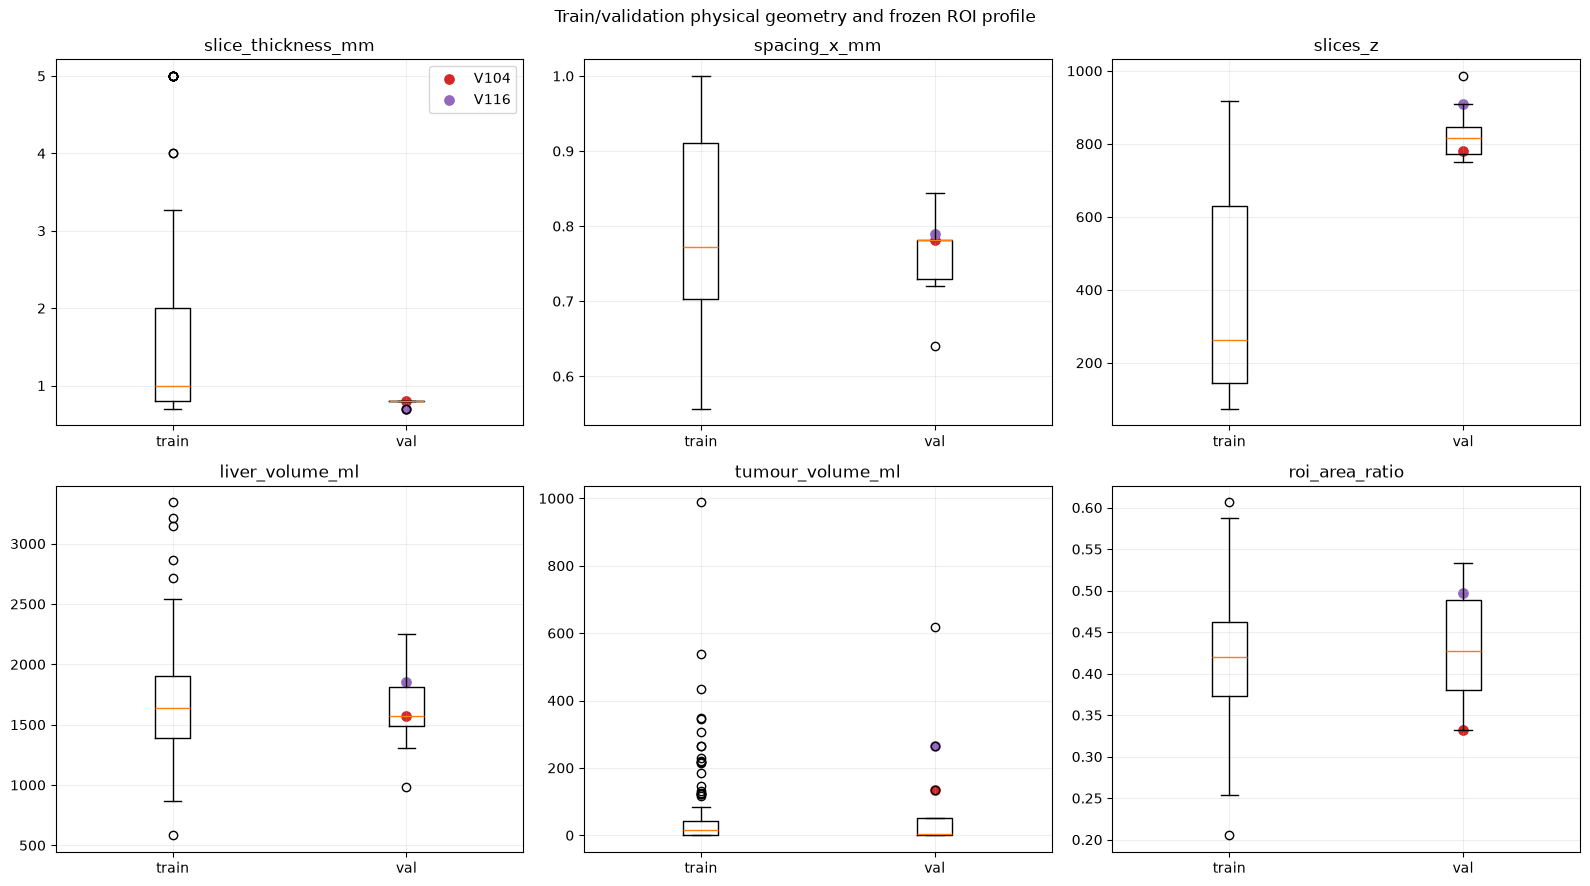

,split,volume_id,shape_x,shape_y,slices_z,spacing_x_mm,spacing_y_mm,slice_thickness_mm,voxel_volume_mm3,fov_x_mm,fov_y_mm,fov_z_mm,axis_codes,affine_determinant,image_segmentation_shape_match,source_raw_affine_match,effective_affine_match_after_transform,affine_alignment_resolved,affine_resolution,liver_volume_ml,tumour_volume_ml,roi_height_px,roi_width_px,roi_height_mm_derived_grid,roi_width_mm_derived_grid,roi_area_ratio,roi_tumour_pixel_containment,roi_positive_slice_containment,transform_applied
104,val,104,512,512,781,0.781000,0.781000,0.8,0.487969,399.872009,399.872009,624.800009,RAS,0.487969,True,False,True,True,numeric_match_after_approved_transform,1574.940381,134.639384,173,126,270.226006,196.812005,0.332611,1.0,1.0,rot180
116,val,116,512,512,908,0.789062,0.789062,0.7,0.435834,404.000000,404.000000,635.599989,RAS,0.435834,True,False,True,True,numeric_match_after_approved_transform,1857.135477,266.351941,180,181,284.062500,285.640625,0.497131,1.0,1.0,rot180


,feature,split,count,q00,q05,q25,q50,q75,q95,q100,mean,std,validation_minus_train_standardized_difference
0,slices_z,train,104,74.000000,93.150000,145.000000,263.000000,629.250000,841.000000,917.000000,391.028846,262.602230,2.244728
1,slices_z,val,13,751.000000,754.000000,771.000000,816.000000,846.000000,939.200000,986.000000,821.923077,68.819161,2.244728
2,spacing_x_mm,train,104,0.556641,0.644531,0.703125,0.772461,0.910156,1.000000,1.000000,0.804876,0.126885,-0.469054
3,spacing_x_mm,val,13,0.640000,0.688000,0.729000,0.781000,0.782000,0.810937,0.843750,0.759832,0.048425,-0.469054
4,spacing_y_mm,train,104,0.556641,0.644531,0.703125,0.772461,0.910156,1.000000,1.000000,0.804876,0.126885,-0.469054
5,spacing_y_mm,val,13,0.640000,0.688000,0.729000,0.781000,0.782000,0.810937,0.843750,0.759832,0.048425,-0.469054
6,slice_thickness_mm,train,104,0.699984,0.700000,0.800000,1.000000,2.000000,5.000000,5.000000,1.634806,1.279375,-0.939391
7,slice_thickness_mm,val,13,0.700000,0.700000,0.800000,0.800000,0.800000,0.800000,0.800000,0.784615,0.037553,-0.939391
8,fov_x_mm,train,104,285.000000,329.999896,360.000000,395.500000,466.000000,512.000000,512.000000,412.096694,64.964938,-0.469054
9,fov_x_mm,val,13,327.679993,352.256006,373.247986,399.872009,400.384003,415.200000,432.000000,389.033846,24.793407,-0.469054


In [6]:
geometry_features=["slices_z","spacing_x_mm","spacing_y_mm","slice_thickness_mm","fov_x_mm","fov_y_mm","fov_z_mm","liver_volume_ml","tumour_volume_ml","roi_area_ratio","roi_height_mm_derived_grid","roi_width_mm_derived_grid"]
geometry_comparison=quantile_summary(geometry,geometry_features); save_csv(geometry_comparison,"geometry_split_comparison.csv")
outlier_rows=[]
for feature in geometry_features:
    q1,q3,low,high=robust_bounds(geometry.loc[geometry.split.eq("train"),feature])
    flagged=geometry[pd.to_numeric(geometry[feature],errors="coerce").lt(low)|pd.to_numeric(geometry[feature],errors="coerce").gt(high)]
    for row in flagged.itertuples(index=False): outlier_rows.append({"split":row.split,"volume_id":row.volume_id,"feature":feature,"value":getattr(row,feature),"train_q1":q1,"train_q3":q3,"lower_bound":low,"upper_bound":high})
geometry_outliers=pd.DataFrame(outlier_rows,columns=["split","volume_id","feature","value","train_q1","train_q3","lower_bound","upper_bound"]); save_csv(geometry_outliers,"geometry_outliers.csv")

fig,axes=plt.subplots(2,3,figsize=(16,9)); plot_features=["slice_thickness_mm","spacing_x_mm","slices_z","liver_volume_ml","tumour_volume_ml","roi_area_ratio"]
for ax,feature in zip(axes.ravel(),plot_features):
    data=[geometry.loc[geometry.split.eq(s),feature].dropna() for s in ALLOWED_SPLITS]; ax.boxplot(data,tick_labels=ALLOWED_SPLITS,showfliers=True); ax.set_title(feature); ax.grid(alpha=.2)
    for focus,color in [(104,"#d62728"),(116,"#9467bd")]:
        row=geometry[geometry.volume_id.eq(focus)];
        if len(row): ax.scatter([2],[row[feature].iloc[0]],color=color,s=45,label=f"V{focus}")
axes[0,0].legend(); fig.suptitle("Train/validation physical geometry and frozen ROI profile"); fig.tight_layout(); fig.savefig(OUTPUT_DIR/"geometry_dashboard.png",dpi=170,bbox_inches="tight"); plt.show()
display(geometry[geometry.volume_id.isin([104,116])]); display(geometry_comparison)

### 7. Train-derived lesion strata, validation coverage, morphology dashboard

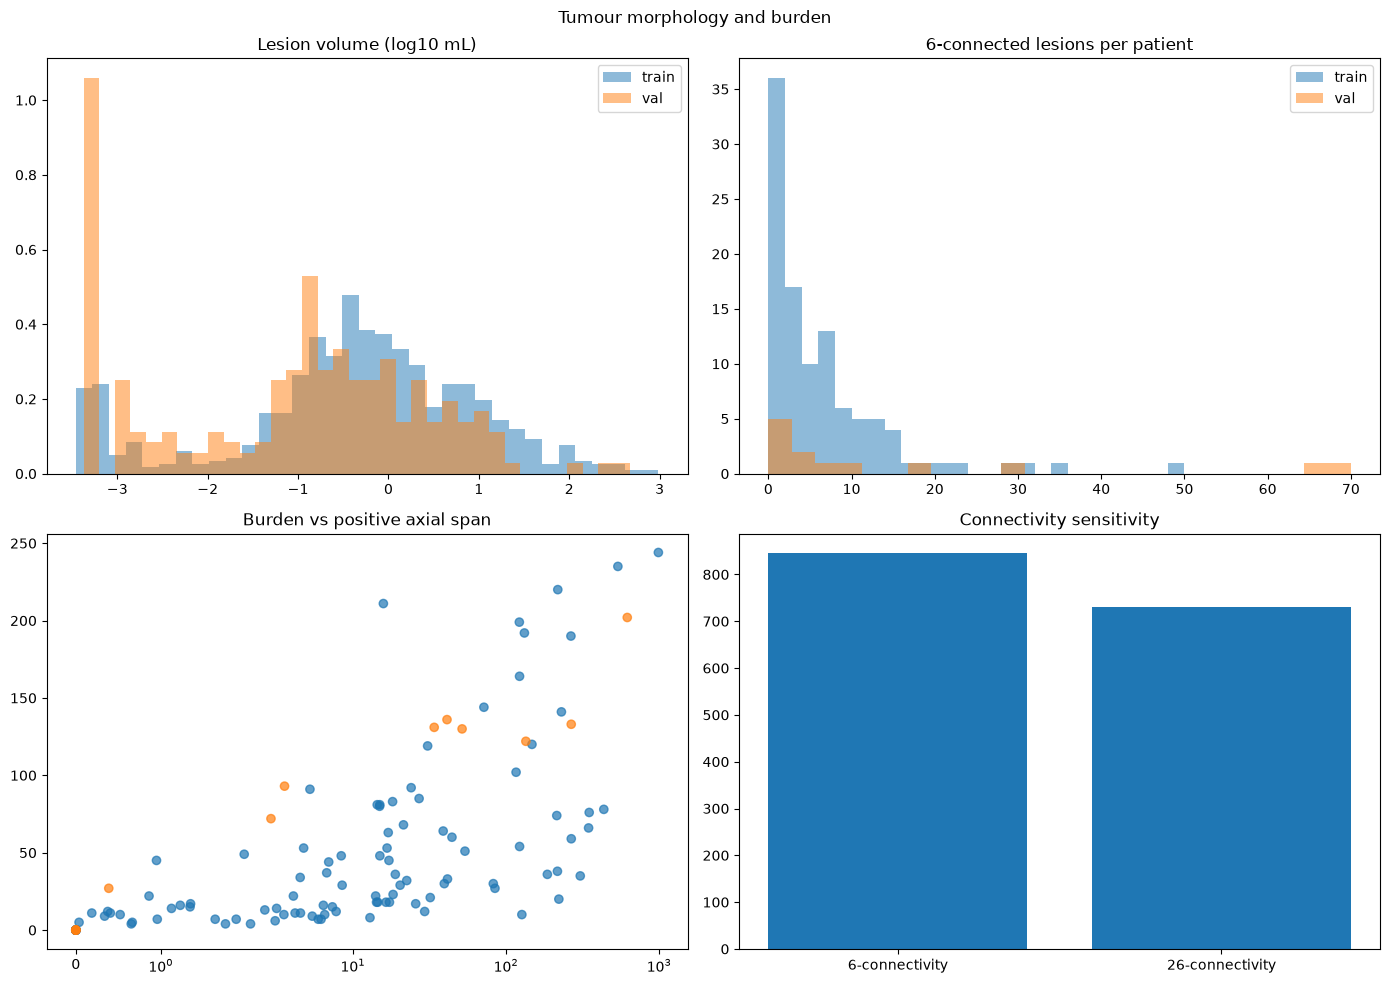

In [7]:
train_lesions=lesions[(lesions.split.eq("train")) & (lesions.physical_volume_ml>=MIN_COMPONENT_ML_FOR_PRIMARY_BINS)].copy()
train_patients=patients[patients.split.eq("train")].copy()
bin_definitions={
    "lesion_volume_ml":derive_train_edges(train_lesions.physical_volume_ml),
    "equivalent_spherical_diameter_mm":derive_train_edges(train_lesions.equivalent_spherical_diameter_mm),
    "patient_tumour_volume_ml":derive_train_edges(train_patients.tumour_volume_ml),
    "patient_lesion_count":derive_train_edges(train_patients.lesion_count_6conn),
    "derivation_split":"train", "random_seed":RANDOM_SEED, "validation_used_to_fit":False,
    "tiny_component_threshold_ml":MIN_COMPONENT_ML_FOR_PRIMARY_BINS, "connectivity":CONNECTIVITY_DEFAULT}
write_json(OUTPUT_DIR/"train_derived_lesion_bins.json",bin_definitions)
lesions["lesion_volume_stratum"]=assign_bin(lesions.physical_volume_ml,bin_definitions["lesion_volume_ml"],"lesion_volume")
lesions["diameter_stratum"]=assign_bin(lesions.equivalent_spherical_diameter_mm,bin_definitions["equivalent_spherical_diameter_mm"],"diameter")
patients["burden_stratum"]=assign_bin(patients.tumour_volume_ml,bin_definitions["patient_tumour_volume_ml"],"burden")
coverage=pd.concat([
    lesions.groupby(["split","lesion_volume_stratum"],dropna=False).size().rename("count").reset_index().assign(stratum_family="lesion_volume"),
    lesions.groupby(["split","diameter_stratum"],dropna=False).size().rename("count").reset_index().rename(columns={"diameter_stratum":"lesion_volume_stratum"}).assign(stratum_family="diameter"),
    patients.groupby(["split","burden_stratum"],dropna=False).size().rename("count").reset_index().rename(columns={"burden_stratum":"lesion_volume_stratum"}).assign(stratum_family="patient_burden")],ignore_index=True)
save_csv(coverage,"validation_stratum_coverage.csv"); save_csv(lesions,"lesion_or_size_metrics.csv")
fig,axes=plt.subplots(2,2,figsize=(14,10))
for split,color in [("train","#1f77b4"),("val","#ff7f0e")]:
    vals=lesions.loc[lesions.split.eq(split)&lesions.physical_volume_ml.gt(0),"physical_volume_ml"]; axes[0,0].hist(np.log10(vals),bins=35,alpha=.5,label=split,color=color,density=True)
    axes[0,1].hist(patients.loc[patients.split.eq(split),"lesion_count_6conn"],bins=25,alpha=.5,label=split,color=color)
axes[0,0].set_title("Lesion volume (log10 mL)"); axes[0,1].set_title("6-connected lesions per patient"); axes[0,0].legend(); axes[0,1].legend()
axes[1,0].scatter(patients.tumour_volume_ml,patients.tumour_positive_slice_count,c=patients.split.map({"train":"#1f77b4","val":"#ff7f0e"}),alpha=.7); axes[1,0].set_xscale("symlog"); axes[1,0].set_title("Burden vs positive axial span")
axes[1,1].bar(["6-connectivity","26-connectivity"],[lesions.shape[0],patients.lesion_count_26conn.sum()]); axes[1,1].set_title("Connectivity sensitivity")
fig.suptitle("Tumour morphology and burden"); fig.tight_layout(); fig.savefig(OUTPUT_DIR/"lesion_distribution_dashboard.png",dpi=170,bbox_inches="tight"); plt.show()

### 8. HU/appearance shift, train-only analog search, and focus-patient dashboards

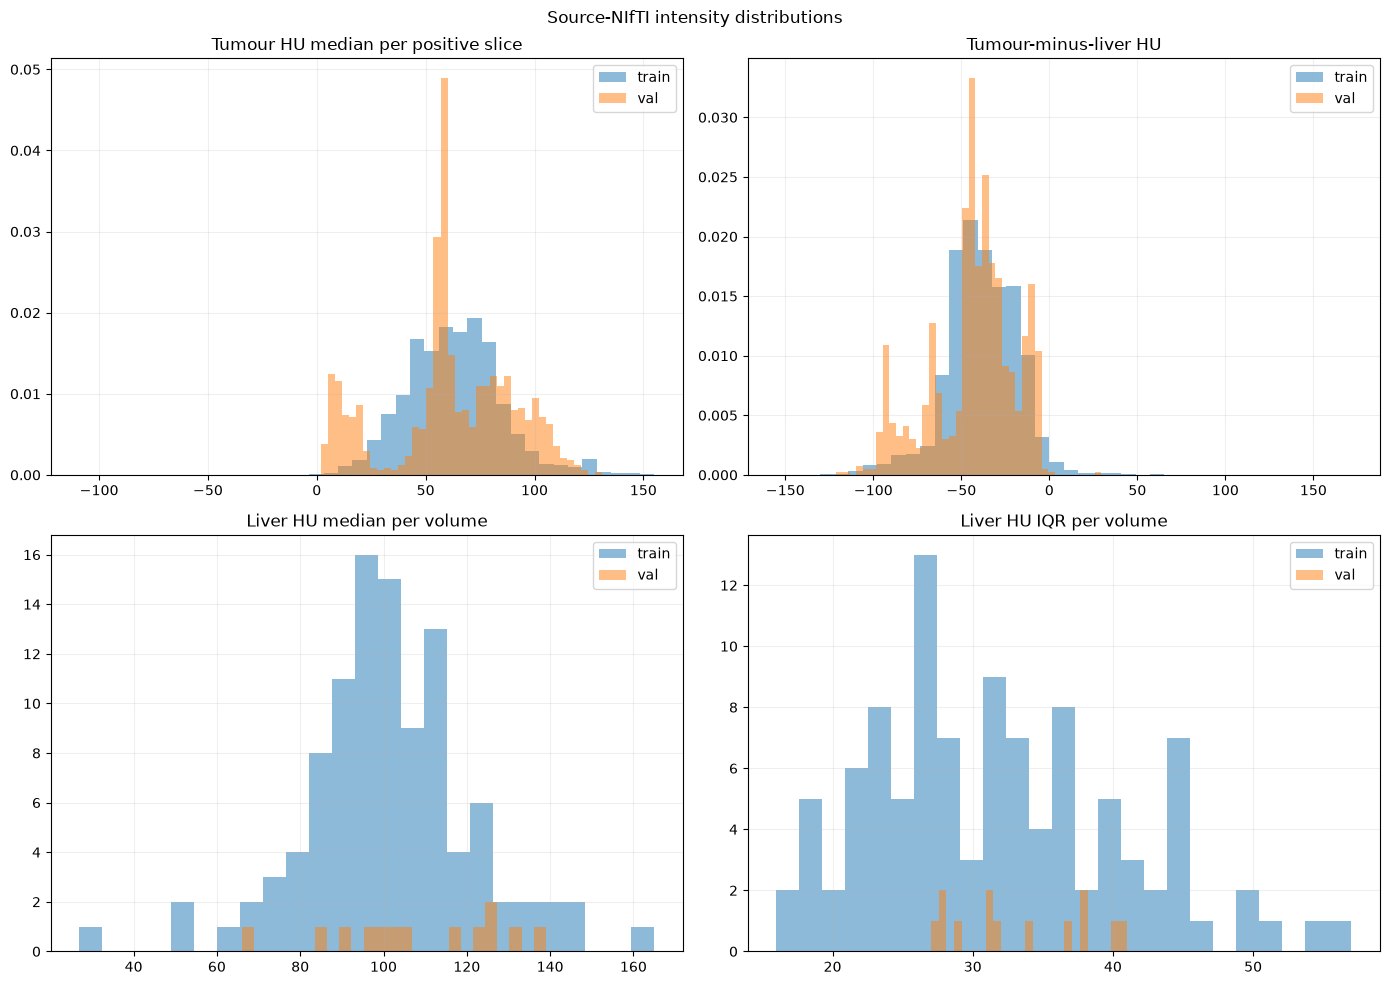

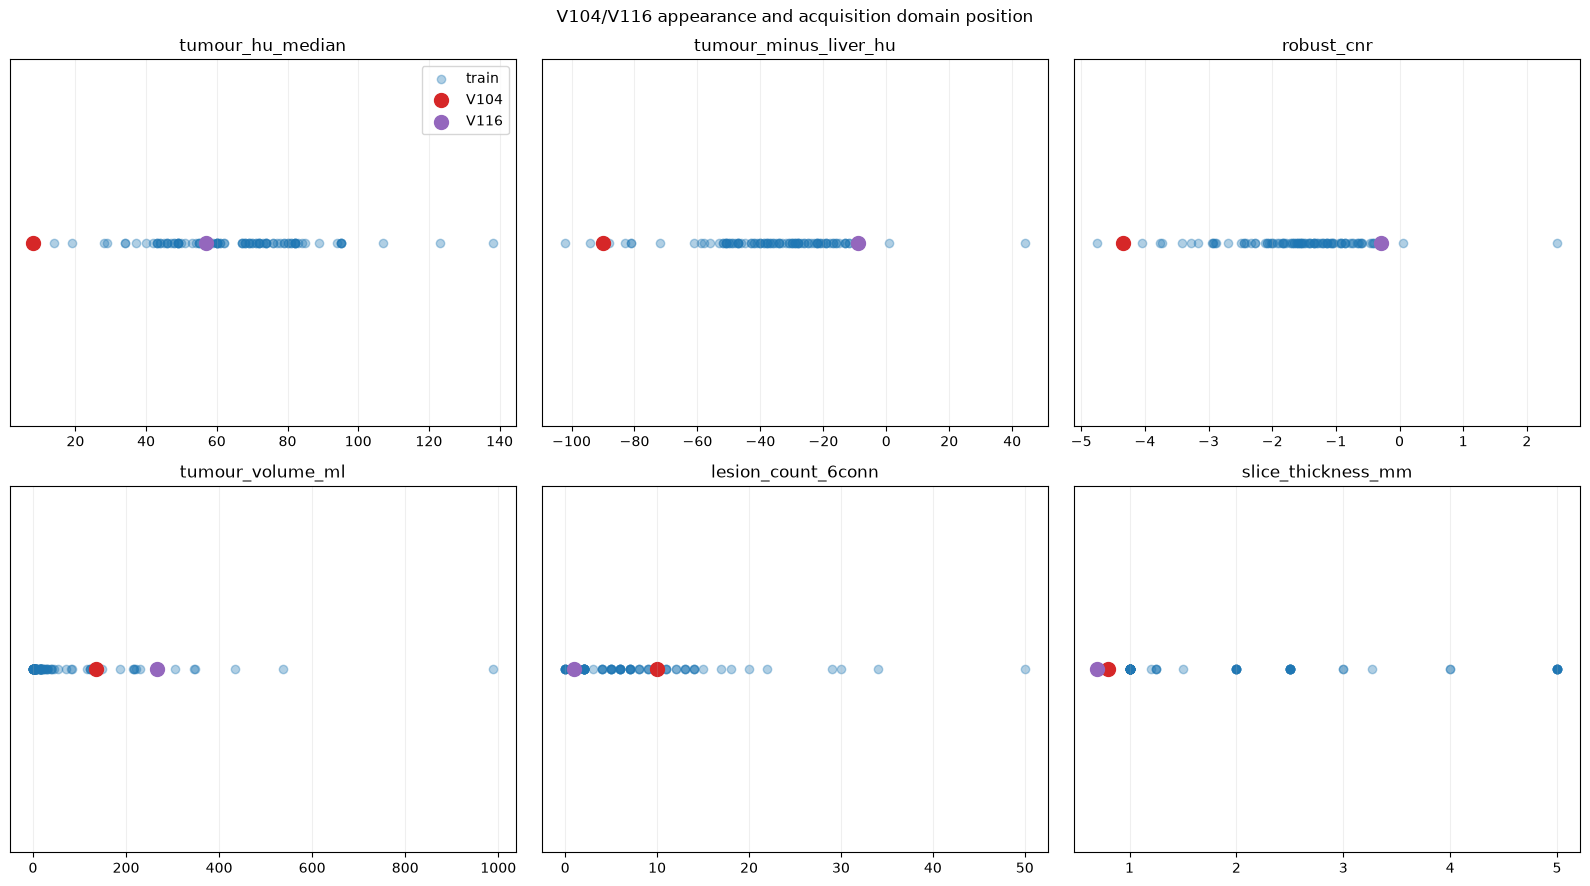

,validation_volume_id,train_volume_id,rank,train_scaled_euclidean_distance,features
0,104,64,1,3.259936,"['tumour_hu_median', 'liver_hu_median', 'liver..."
1,104,90,2,3.448320,"['tumour_hu_median', 'liver_hu_median', 'liver..."
2,104,88,3,3.830144,"['tumour_hu_median', 'liver_hu_median', 'liver..."
3,104,27,4,3.839096,"['tumour_hu_median', 'liver_hu_median', 'liver..."
4,104,93,5,4.364941,"['tumour_hu_median', 'liver_hu_median', 'liver..."
60,116,84,1,2.573902,"['tumour_hu_median', 'liver_hu_median', 'liver..."
61,116,44,2,3.647485,"['tumour_hu_median', 'liver_hu_median', 'liver..."
62,116,97,3,3.771641,"['tumour_hu_median', 'liver_hu_median', 'liver..."
63,116,51,4,3.948063,"['tumour_hu_median', 'liver_hu_median', 'liver..."
64,116,28,5,3.999142,"['tumour_hu_median', 'liver_hu_median', 'liver..."


In [8]:
appearance=geometry.merge(patients,on=["split","volume_id"],suffixes=("","_burden")).merge(hu_volumes,on=["split","volume_id"])
appearance_features=["tumour_hu_median","tumour_hu_iqr","liver_hu_median","liver_hu_iqr","tumour_minus_liver_hu","robust_cnr","background_hu_median","slice_thickness_mm","spacing_x_mm","tumour_volume_ml","lesion_count_6conn","roi_area_ratio"]
appearance_profile=quantile_summary(appearance,appearance_features); save_csv(appearance_profile,"appearance_feature_profile.csv")
analog_features=["tumour_hu_median","liver_hu_median","liver_hu_iqr","tumour_minus_liver_hu","robust_cnr","slice_thickness_mm","spacing_x_mm","tumour_volume_ml","lesion_count_6conn","roi_area_ratio"]
train_a=appearance[appearance.split.eq("train")].copy(); val_a=appearance[appearance.split.eq("val")].copy()
medians=train_a[analog_features].median(); scaler=RobustScaler().fit(train_a[analog_features].fillna(medians)); train_scaled=scaler.transform(train_a[analog_features].fillna(medians)); val_scaled=scaler.transform(val_a[analog_features].fillna(medians))
analog_rows=[]
for i,vrow in enumerate(val_a.itertuples(index=False)):
    distances=np.linalg.norm(train_scaled-val_scaled[i],axis=1); order=np.argsort(distances)[:ANALOG_TOP_K]
    for rank,j in enumerate(order,1): analog_rows.append({"validation_volume_id":int(vrow.volume_id),"train_volume_id":int(train_a.iloc[j].volume_id),"rank":rank,"train_scaled_euclidean_distance":float(distances[j]),"features":repr(analog_features)})
analogs=pd.DataFrame(analog_rows); save_csv(analogs,"validation_training_analogs.csv")

fig,axes=plt.subplots(2,2,figsize=(14,10))
for split,color in [("train","#1f77b4"),("val","#ff7f0e")]:
    axes[0,0].hist(hu_slices.loc[hu_slices.split.eq(split),"tumour_hu_median"].dropna(),bins=40,alpha=.5,density=True,label=split,color=color)
    axes[0,1].hist(hu_slices.loc[hu_slices.split.eq(split),"tumour_minus_liver_hu"].dropna(),bins=40,alpha=.5,density=True,label=split,color=color)
    axes[1,0].hist(hu_volumes.loc[hu_volumes.split.eq(split),"liver_hu_median"].dropna(),bins=25,alpha=.5,label=split,color=color)
    axes[1,1].hist(hu_volumes.loc[hu_volumes.split.eq(split),"liver_hu_iqr"].dropna(),bins=25,alpha=.5,label=split,color=color)
for ax in axes.ravel(): ax.legend(); ax.grid(alpha=.2)
axes[0,0].set_title("Tumour HU median per positive slice"); axes[0,1].set_title("Tumour-minus-liver HU"); axes[1,0].set_title("Liver HU median per volume"); axes[1,1].set_title("Liver HU IQR per volume")
fig.suptitle("Source-NIfTI intensity distributions"); fig.tight_layout(); fig.savefig(OUTPUT_DIR/"intensity_distribution_dashboard.png",dpi=170,bbox_inches="tight"); plt.show()

focus=appearance[appearance.volume_id.isin([104,116])].set_index("volume_id"); fig,axes=plt.subplots(2,3,figsize=(16,9))
focus_features=["tumour_hu_median","tumour_minus_liver_hu","robust_cnr","tumour_volume_ml","lesion_count_6conn","slice_thickness_mm"]
for ax,feature in zip(axes.ravel(),focus_features):
    ax.scatter(train_a[feature],np.zeros(len(train_a)),alpha=.35,label="train")
    for vid,color in [(104,"#d62728"),(116,"#9467bd")]:
        if vid in focus.index: ax.scatter([focus.loc[vid,feature]],[0],s=100,color=color,label=f"V{vid}")
    ax.set_title(feature); ax.set_yticks([]); ax.grid(alpha=.2)
axes[0,0].legend(); fig.suptitle("V104/V116 appearance and acquisition domain position"); fig.tight_layout(); fig.savefig(OUTPUT_DIR/"v104_v116_domain_dashboard.png",dpi=170,bbox_inches="tight"); plt.show()
display(analogs[analogs.validation_volume_id.isin([104,116])])

### 9. Label-alignment visual review and critical QC gate

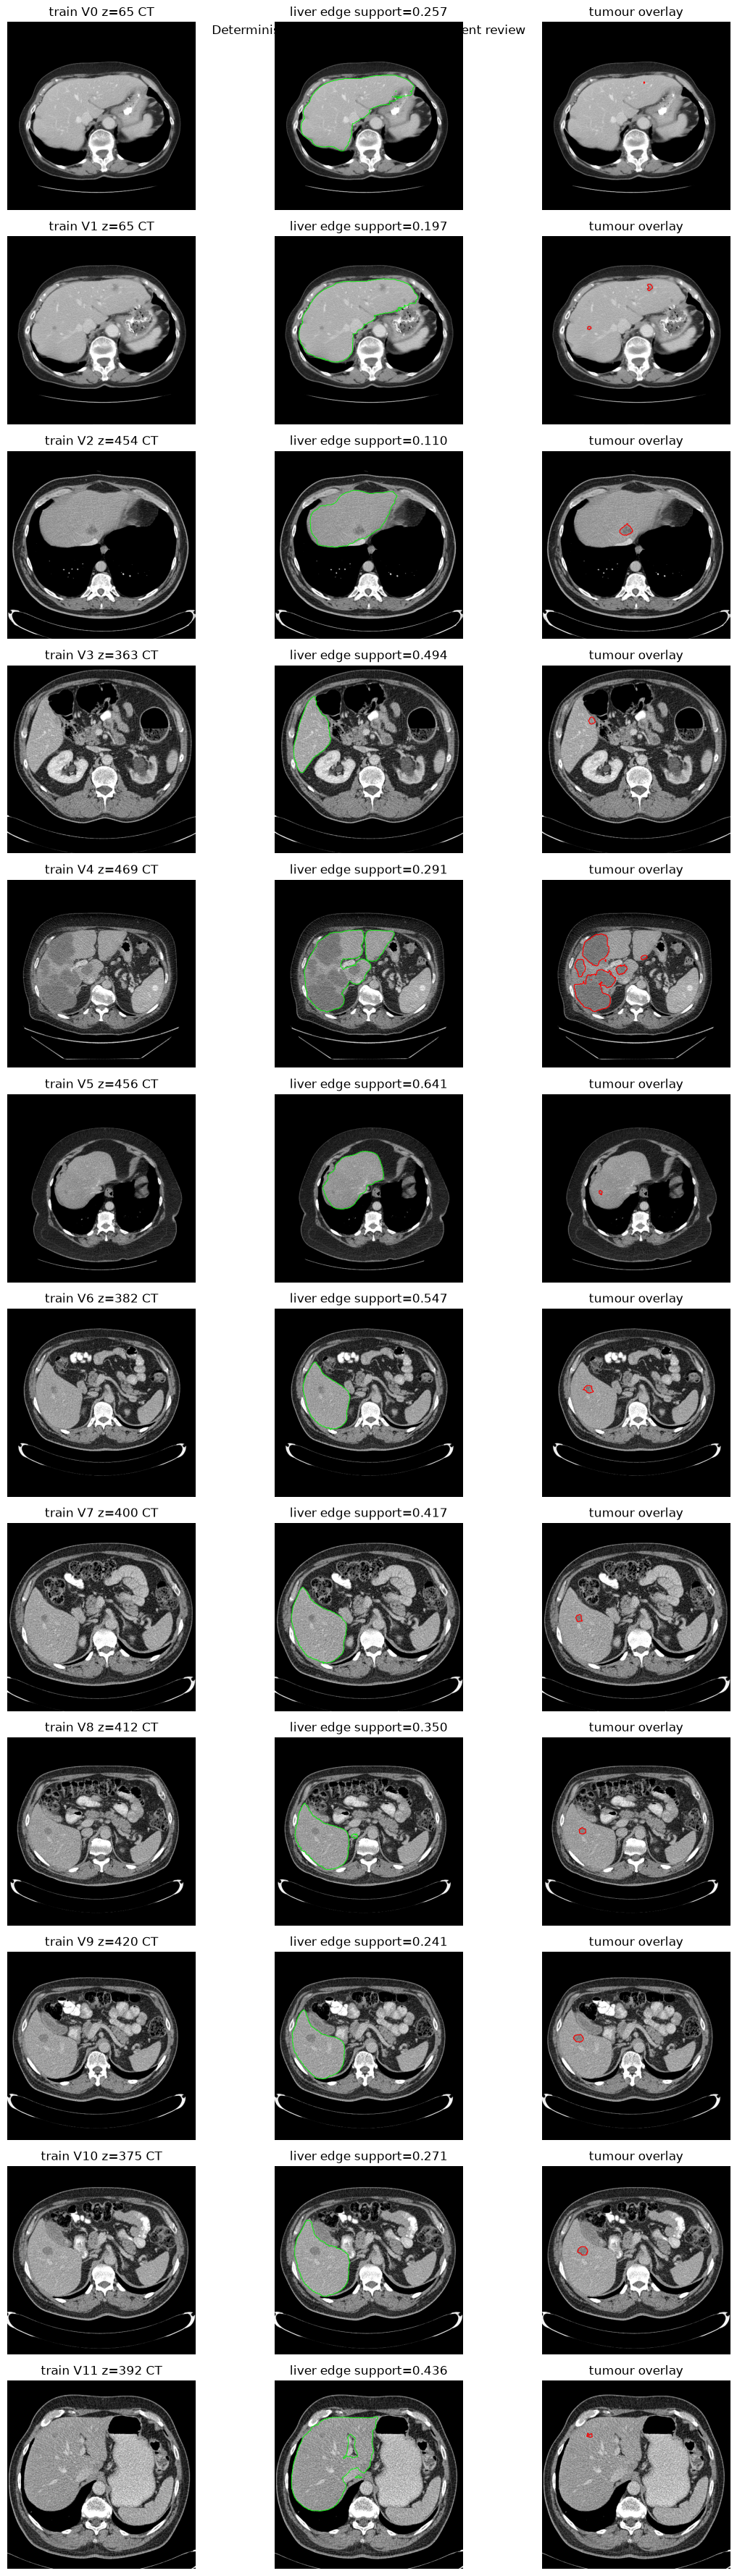

Critical label/geometry rows: 0


,split,volume_id,source_labels,labels_valid_0_1_2,tumour_containment_fraction,components_6conn,components_26conn,tiny_components_under_0_001_ml,max_consecutive_centroid_jump_vox,max_consecutive_area_ratio,shape_match,raw_affine_match,effective_affine_match_after_transform,affine_alignment_resolved,affine_resolution,roi_tumour_pixel_containment
104,val,104,"[0, 1, 2]",True,1.0,10,6,2,28.817705,1.909091,True,False,True,True,numeric_match_after_approved_transform,1.0
116,val,116,"[0, 1, 2]",True,1.0,1,1,0,2.779328,1.105871,True,False,True,True,numeric_match_after_approved_transform,1.0


In [9]:
n=len(alignment_cases); fig,axes=plt.subplots(n,3,figsize=(12,max(3,3*n)),squeeze=False)
for r,(split,vid,z,image2d,liver2d,tumour2d,score) in enumerate(alignment_cases):
    axes[r,0].imshow(image2d.T,cmap="gray",origin="lower",vmin=BROAD_WINDOW[0],vmax=BROAD_WINDOW[1]); axes[r,0].set_title(f"{split} V{vid} z={z} CT")
    axes[r,1].imshow(image2d.T,cmap="gray",origin="lower",vmin=BROAD_WINDOW[0],vmax=BROAD_WINDOW[1]); axes[r,1].contour(liver2d.T,levels=[.5],colors="lime",linewidths=.6); axes[r,1].set_title(f"liver edge support={score:.3f}")
    axes[r,2].imshow(image2d.T,cmap="gray",origin="lower",vmin=BROAD_WINDOW[0],vmax=BROAD_WINDOW[1]); axes[r,2].contour(tumour2d.T,levels=[.5],colors="red",linewidths=.8); axes[r,2].set_title("tumour overlay")
    for ax in axes[r]: ax.axis("off")
fig.suptitle("Deterministic source image/label alignment review"); fig.tight_layout(); fig.savefig(OUTPUT_DIR/"label_alignment_review.png",dpi=170,bbox_inches="tight"); plt.show()
containment_failure_mask=label_qc.tumour_containment_fraction.notna() & label_qc.tumour_containment_fraction.lt(1-1e-12)
roi_failure_mask=label_qc.roi_tumour_pixel_containment.notna() & label_qc.roi_tumour_pixel_containment.lt(1-1e-12)
critical_label=(~label_qc.labels_valid_0_1_2)|(~label_qc.shape_match)|(~label_qc.affine_alignment_resolved)|containment_failure_mask|roi_failure_mask
print("Critical label/geometry rows:",int(critical_label.sum()))
display(label_qc[label_qc.volume_id.isin([104,116])])

### 10. Section F — join existing Mark 4E diagnostics after feature computation

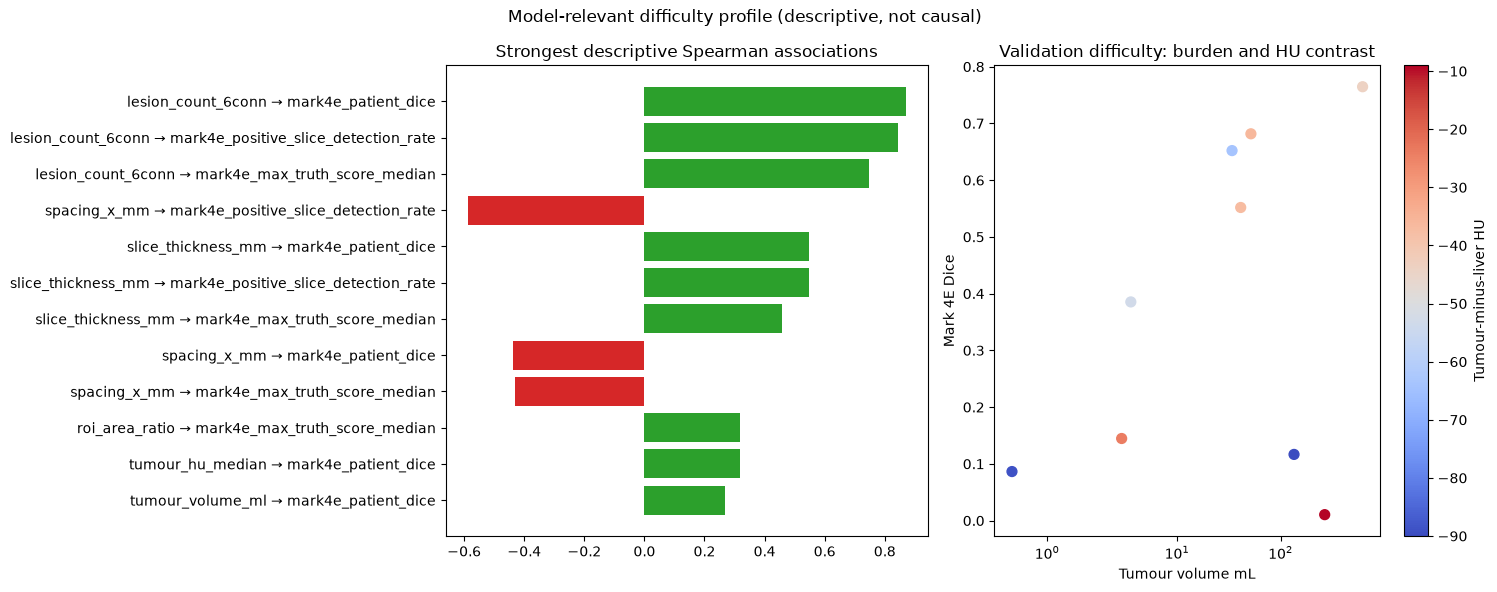

,split,volume_id,shape_x,shape_y,slices_z,spacing_x_mm,spacing_y_mm,slice_thickness_mm,voxel_volume_mm3,fov_x_mm,fov_y_mm,fov_z_mm,axis_codes,affine_determinant,image_segmentation_shape_match,source_raw_affine_match,effective_affine_match_after_transform,affine_alignment_resolved,affine_resolution,liver_volume_ml,tumour_volume_ml,roi_height_px,roi_width_px,roi_height_mm_derived_grid,roi_width_mm_derived_grid,roi_area_ratio,roi_tumour_pixel_containment,roi_positive_slice_containment,transform_applied,lesion_count_6conn,lesion_count_26conn,tiny_component_connectivity_difference,tumour_volume_ml_burden,liver_volume_ml_burden,tumour_to_liver_ratio,tumour_positive_slice_count,tumour_positive_slice_continuity,multifocal,largest_lesion_ml,median_lesion_ml,burden_stratum,tumour_hu_median,tumour_hu_iqr,liver_hu_median,liver_hu_iqr,tumour_minus_liver_hu,robust_cnr,background_hu_median,background_hu_iqr,tumour_broad_window_visibility,tumour_liver_window_visibility,liver_broad_window_visibility,liver_liver_window_visibility,mark4e_patient_dice,mark4e_has_tumour,mark4e_positive_slices,mark4e_detected_positive_slices,mark4e_max_truth_score_median,mark4e_positive_slice_detection_rate
104,val,104,512,512,781,0.781000,0.781000,0.8,0.487969,399.872009,399.872009,624.800009,RAS,0.487969,True,False,True,True,numeric_match_after_approved_transform,1574.940381,134.639384,173,126,270.226006,196.812005,0.332611,1.0,1.0,rot180,10,6,4,134.639384,1574.940381,0.085489,122,0.797386,True,130.649262,0.037818,burden_q4,8.0,26.0,98.0,28.0,-90.0,-4.336071,-986.0,923.0,0.996365,0.67598,0.997349,0.991560,0.116627,True,122.0,47.0,0.0,0.385246
116,val,116,512,512,908,0.789062,0.789062,0.7,0.435834,404.000000,404.000000,635.599989,RAS,0.435834,True,False,True,True,numeric_match_after_approved_transform,1857.135477,266.351941,180,181,284.062500,285.640625,0.497131,1.0,1.0,rot180,1,1,0,266.351941,1857.135477,0.143421,133,1.000000,False,266.351941,266.351941,burden_q4,57.0,42.0,66.0,41.0,-9.0,-0.296122,-862.0,945.0,0.999993,0.96755,0.999983,0.981842,0.010474,True,133.0,11.0,0.0,0.082707


,feature,outcome,n,spearman_rho,p_value_unadjusted,analysis_population,interpretation
30,lesion_count_6conn,mark4e_patient_dice,9,0.870301,0.002274,nine_tumour_positive_validation_patients,association_only_not_causal
31,lesion_count_6conn,mark4e_positive_slice_detection_rate,9,0.845196,0.004117,tumour_positive_slices_aggregated_by_patient,association_only_not_causal
32,lesion_count_6conn,mark4e_max_truth_score_median,9,0.748481,0.020336,tumour_positive_slices_aggregated_by_patient,association_only_not_causal
25,spacing_x_mm,mark4e_positive_slice_detection_rate,9,-0.588256,0.095679,tumour_positive_slices_aggregated_by_patient,association_only_not_causal
21,slice_thickness_mm,mark4e_patient_dice,9,0.547723,0.126870,nine_tumour_positive_validation_patients,association_only_not_causal
22,slice_thickness_mm,mark4e_positive_slice_detection_rate,9,0.547723,0.126870,tumour_positive_slices_aggregated_by_patient,association_only_not_causal
23,slice_thickness_mm,mark4e_max_truth_score_median,9,0.459279,0.213620,tumour_positive_slices_aggregated_by_patient,association_only_not_causal
24,spacing_x_mm,mark4e_patient_dice,9,-0.436990,0.239545,nine_tumour_positive_validation_patients,association_only_not_causal
26,spacing_x_mm,mark4e_max_truth_score_median,9,-0.432196,0.245332,tumour_positive_slices_aggregated_by_patient,association_only_not_causal
35,roi_area_ratio,mark4e_max_truth_score_median,9,0.316776,0.406226,tumour_positive_slices_aggregated_by_patient,association_only_not_causal


In [10]:
mark4e_patients=pd.read_csv(MARK4E_DIR/"fusion_patient_metrics.csv")
selected_patient=mark4e_patients[(mark4e_patients.policy.eq("maximum")) & np.isclose(mark4e_patients.threshold,0.70)].copy()
selected_patient=selected_patient.rename(columns={"dice":"mark4e_patient_dice","has_tumor":"mark4e_has_tumour"})
mark4e_slices=pd.read_csv(MARK4E_DIR/"fusion_positive_slice_diagnostic.csv")
selected_slices=mark4e_slices[mark4e_slices.policy.eq("maximum")].copy()
patient_difficulty=appearance.merge(selected_patient[["volume_id","mark4e_patient_dice","mark4e_has_tumour"]],on="volume_id",how="left")
slice_agg=selected_slices.groupby("volume_id").agg(mark4e_positive_slices=("slice_index","size"),mark4e_detected_positive_slices=("detected","sum"),mark4e_max_truth_score_median=("max_truth_probability","median")).reset_index()
patient_difficulty=patient_difficulty.merge(slice_agg,on="volume_id",how="left")
patient_difficulty["mark4e_positive_slice_detection_rate"]=patient_difficulty.mark4e_detected_positive_slices/patient_difficulty.mark4e_positive_slices
assoc_rows=[]
outcomes=["mark4e_patient_dice","mark4e_positive_slice_detection_rate","mark4e_max_truth_score_median"]
for feature in appearance_features:
    for outcome in outcomes:
        eligible=patient_difficulty.mark4e_has_tumour.eq(True) if outcome=="mark4e_patient_dice" else patient_difficulty[outcome].notna()
        subset=patient_difficulty.loc[eligible,[feature,outcome]].dropna()
        if len(subset)>=5:
            rho,p=stats.spearmanr(subset[feature],subset[outcome]); assoc_rows.append({"feature":feature,"outcome":outcome,"n":len(subset),"spearman_rho":rho,"p_value_unadjusted":p,
                "analysis_population":"nine_tumour_positive_validation_patients" if outcome=="mark4e_patient_dice" else "tumour_positive_slices_aggregated_by_patient",
                "interpretation":"association_only_not_causal"})
associations=pd.DataFrame(assoc_rows); save_csv(associations,"difficulty_feature_associations.csv"); save_csv(patient_difficulty,"patient_difficulty_profile.csv")
save_csv(patient_difficulty,"patient_metrics.csv"); save_csv(selected_slices,"slice_metrics.csv")

top=associations.reindex(associations.spearman_rho.abs().sort_values(ascending=False).index).head(12)
fig,axes=plt.subplots(1,2,figsize=(15,6)); axes[0].barh(top.feature+" → "+top.outcome,top.spearman_rho,color=np.where(top.spearman_rho>=0,"#2ca02c","#d62728")); axes[0].invert_yaxis(); axes[0].set_title("Strongest descriptive Spearman associations")
positives=patient_difficulty[patient_difficulty.mark4e_has_tumour.eq(True)]; sc=axes[1].scatter(positives.tumour_volume_ml,positives.mark4e_patient_dice,c=positives.tumour_minus_liver_hu,cmap="coolwarm",s=50); axes[1].set_xscale("symlog"); axes[1].set_xlabel("Tumour volume mL"); axes[1].set_ylabel("Mark 4E Dice"); axes[1].set_title("Validation difficulty: burden and HU contrast"); fig.colorbar(sc,ax=axes[1],label="Tumour-minus-liver HU")
fig.suptitle("Model-relevant difficulty profile (descriptive, not causal)"); fig.tight_layout(); fig.savefig(OUTPUT_DIR/"difficulty_dashboard.png",dpi=170,bbox_inches="tight"); plt.show()
display(patient_difficulty[patient_difficulty.volume_id.isin([104,116])]); display(top)

### 11. Freeze the train-derived sampling policy, data card, provenance, and gate

In [11]:
# Conservative default: stratification definitions are frozen, but weights remain uniform unless train-only evidence proves scarcity.
train_stratum_counts=patients[patients.split.eq("train")].groupby("burden_stratum",dropna=False).size()
sampling_policy={"status":"FROZEN_TRAIN_DERIVED_POLICY","policy":"uniform_patient_aware_existing_sampler_no_change",
    "derivation_split":"train","validation_used_to_fit":False,"test_used":False,"random_seed":RANDOM_SEED,
    "bin_edges":bin_definitions,"weights":{"default":1.0},"caps":{"maximum_weight":1.0,"minimum_weight":1.0},
    "train_stratum_counts":{str(k):int(v) for k,v in train_stratum_counts.items()},
    "rationale":"Dataset characterization defines reproducible strata, but descriptive validation failures do not justify validation-patient-specific weights. Retain the existing sampler unless a later bounded train-only intervention is predeclared."}
write_json(OUTPUT_DIR/"sampling_policy.json",sampling_policy)

critical_integrity=critical_count>0; critical_geometry=bool((~geometry.image_segmentation_shape_match).any() or (~geometry.affine_alignment_resolved).any())
critical_labels=bool((~label_qc.labels_valid_0_1_2).any() or ((label_qc.tumour_containment_fraction.notna()) & (label_qc.tumour_containment_fraction<1-1e-12)).any())
critical_roi=bool((geometry.roi_tumour_pixel_containment.dropna()<1-1e-12).any())
if critical_integrity or critical_geometry or critical_labels or critical_roi:
    decision="HOLD_FIX_DATA_OR_LABEL_ISSUE"; result_level="FAILED_GATE"
else:
    decision="PASS_FREEZE_DATA_CARD_AND_PROCEED_TO_FUSION_CONFIRMATION"; result_level="DIAGNOSTIC_COMPLETE"
gate_checks=[
    ("manifest_identity",not critical_integrity,"critical","manifest/integrity"),("train_validation_leakage",not source_overlap,"critical","no patient/source hash overlap"),
    ("geometry_affine",not critical_geometry,"critical","source image/segmentation agreement"),("label_semantics_containment",not critical_labels,"critical","labels and containment"),
    ("frozen_roi_coverage",not critical_roi,"critical","tumour containment"),("geometry_profile_complete",len(geometry)==manifest.volume_id.nunique(),"required",len(geometry)),
    ("morphology_profile_complete",len(patients)==manifest.volume_id.nunique(),"required",len(patients)),
    ("hu_profile_complete",len(hu_volumes)==manifest.volume_id.nunique(),"required",len(hu_volumes)),
    ("focus_v104_v116_present",{104,116}<=set(appearance.volume_id),"required",sorted(set(appearance.volume_id)&{104,116})),
    ("train_derived_bins_saved",bool(bin_definitions["lesion_volume_ml"]),"required","train only"),("sampling_policy_train_only",sampling_policy["validation_used_to_fit"] is False,"critical",sampling_policy["policy"]),
    ("test_images_accessed_false",TEST_IMAGES_ACCESSED is False,"critical",False)]
expected_vs_actual=pd.DataFrame(gate_checks,columns=["requirement","passed","severity","actual"]); expected_vs_actual["expected"]="pass"; save_csv(expected_vs_actual,"expected_vs_actual.csv")

data_card=f'''# LiTS Corrected v2 Dataset Data Card\n\nGenerated: {datetime.now(timezone.utc).isoformat()}\n\n## Identity and safeguards\n\n- Build: `build_corrected_20260713_214847_v2`\n- Manifest SHA-256: `{manifest_hash}`\n- Allowed audit splits: train and validation only\n- Test images accessed: `false`\n- Target: tumour-only foreground; liver support is stored/derived separately\n- Derived preprocessing: HU window [-160, 240], 256 x 256, bilinear image and nearest-neighbour mask resizing\n\n## Population\n\n```csv\n{split_summary.to_csv(index=False)}\n```\n\n## Geometry\n\n```csv\n{geometry_comparison.to_csv(index=False)}\n```\n\n## Lesion morphology and burden\n\n- 6-connected components are primary; 26-connectivity is reported as sensitivity.\n- Train-derived bin definitions: `train_derived_lesion_bins.json`.\n- Train lesions: {int((lesions.split=='train').sum())}; validation lesions: {int((lesions.split=='val').sum())}.\n- V104 and V116 are explicitly retained in geometry, appearance, QC, analog, and difficulty outputs.\n\n## HU and appearance\n\n```csv\n{appearance_profile.to_csv(index=False)}\n```\n\n## Known outliers and limitations\n\n- Outliers use train Q1/Q3 plus or minus 1.5 IQR and are labelled, never automatically deleted.\n- Near-duplicate signatures are screening evidence, not proof of shared acquisition identity.\n- Source annotation edges receive deterministic visual review, but automated edge support is not a substitute for expert radiological adjudication.\n- Difficulty correlations are descriptive and do not establish causality.\n- Validation phenotypes do not define training weights or preprocessing.\n\n## Sampling policy\n\n- `{sampling_policy['policy']}` with seed {RANDOM_SEED}.\n- All bins and scaling definitions are train-derived.\n- Exact policy: `sampling_policy.json`.\n\n## Gate\n\n- Decision: `{decision}`\n- Result level: `{result_level}`\n- Test images accessed: `false`\n'''
(OUTPUT_DIR/"DATASET_DATA_CARD.md").write_text(data_card,encoding="utf-8")
provenance={"created_utc":datetime.now(timezone.utc).isoformat(),"notebook":str(PHASE_DIR/"step_01_pretraining_dataset_characterization.ipynb"),
    "manifest_sha256":manifest_hash,"dataset_build_id":"build_corrected_20260713_214847_v2","source_volume_count":len(unique_sources),
    "train_val_rows":len(manifest),"train_val_volumes":manifest.volume_id.nunique(),"test_rows_metadata_count_only":len(test_rows),
    "input_artifact_hashes":{"mark_4d_gate":sha256_file(MARK4D_DIR/"mark_4d_gate_result.json"),"mark_4e_gate":sha256_file(MARK4E_DIR/"mark_4e_gate_result.json"),
        "mark_4e_patient_metrics":sha256_file(MARK4E_DIR/"fusion_patient_metrics.csv"),"train_roi_manifest":sha256_file(TRAIN_ROI_PATH),"validation_roi_manifest":sha256_file(VAL_ROI_PATH)},
    "software":{"python":sys.version,"platform":platform.platform(),"numpy":np.__version__,"pandas":pd.__version__,"nibabel":nib.__version__},
    "random_seed":RANDOM_SEED,"test_images_accessed":False,"source_hashes_verified_train_val":True}
write_json(OUTPUT_DIR/"provenance.json",provenance)
gate={"status":"pretraining_dataset_audit_complete" if decision.startswith("PASS") else "pretraining_dataset_audit_hold",
    "result_level":result_level,"selected_configuration":{"sampling_policy":sampling_policy["policy"],"connectivity":CONNECTIVITY_DEFAULT,"outlier_rule":"train 1.5xIQR"},
    "selected_metrics":{"train_val_rows":len(manifest),"train_val_volumes":manifest.volume_id.nunique(),"critical_integrity_failures":critical_count,
        "critical_geometry_failures":int(critical_geometry),"critical_label_failures":int(critical_labels),"critical_roi_failures":int(critical_roi)},
    "targets":{r.requirement:"pass" for r in expected_vs_actual.itertuples()},"target_passes":{r.requirement:bool(r.passed) for r in expected_vs_actual.itertuples()},
    "all_mandatory_targets_passed":bool(expected_vs_actual.passed.all()),"decision":decision,
    "next_step":"step_02_fusion_freeze_confirmation" if decision.startswith("PASS") else "repair_and_version_data_before_training",
    "manifest_sha256":manifest_hash,"input_artifact_hashes":provenance["input_artifact_hashes"],"test_images_accessed":False}
write_json(OUTPUT_DIR/"pretraining_dataset_gate.json",gate); write_json(OUTPUT_DIR/"gate_result.json",gate)
configuration["full_analysis_executed"]=True
configuration["completed_utc"]=datetime.now(timezone.utc).isoformat()
write_json(OUTPUT_DIR/"configuration.json",configuration)
missing_outputs=[name for name in EXPECTED_OUTPUTS if not (OUTPUT_DIR/name).exists()]
if missing_outputs: raise RuntimeError(f"Output contract incomplete: {missing_outputs}")
print(json.dumps(gate,indent=2)); print("All required output files exist.")

{
  "status": "pretraining_dataset_audit_complete",
  "result_level": "DIAGNOSTIC_COMPLETE",
  "selected_configuration": {
    "sampling_policy": "uniform_patient_aware_existing_sampler_no_change",
    "connectivity": 6,
    "outlier_rule": "train 1.5xIQR"
  },
  "selected_metrics": {
    "train_val_rows": 51352,
    "train_val_volumes": 117,
    "critical_integrity_failures": 0,
    "critical_geometry_failures": 0,
    "critical_label_failures": 0,
    "critical_roi_failures": 0
  },
  "targets": {
    "manifest_identity": "pass",
    "train_validation_leakage": "pass",
    "geometry_affine": "pass",
    "label_semantics_containment": "pass",
    "frozen_roi_coverage": "pass",
    "geometry_profile_complete": "pass",
    "morphology_profile_complete": "pass",
    "hu_profile_complete": "pass",
    "focus_v104_v116_present": "pass",
    "train_derived_bins_saved": "pass",
    "sampling_policy_train_only": "pass",
    "test_images_accessed_false": "pass"
  },
  "target_passes": {
    "m

## Takeaways

Read the executed `pretraining_dataset_gate.json`, `DATASET_DATA_CARD.md`, and `expected_vs_actual.csv` rather than this unexecuted prose. Advance only if the decision is `PASS_FREEZE_DATA_CARD_AND_PROCEED_TO_FUSION_CONFIRMATION`. A critical manifest, leakage, affine, label, or ROI-coverage failure requires a data/label hold. The test split remains locked in every branch.